In [6]:
import research_and_analysis

In [21]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage, AnyMessage, HumanMessage, SystemMessage
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display, Image

In [8]:
def create_analyst(state):
    """
    Args:
        state: (_type_): _description
    """
    pass

In [9]:
def human_feedback(state):
    """
    Args:
        state: (_type_): _description
    """
    pass

In [10]:
def should_continue(state):
    """
    Args:
        state: (_type_): _description
    """
    pass

In [22]:
memory = MemorySaver()

In [ ]:
class Analyst(BaseModel):
    name: str = Field(description="Name of the analyst.")
    role: str = Field(description="Role of the analyst in the context of the topic.")
    affiliation: str = Field(description="Primary affiliation of the analyst.")
    description: str = Field(description="Description of the analyst focus, conscerns, and motives.")

    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole:{self.role}\nAffiliation:{self.affiliation}\nDescription:{self.description}"

class Perspective(BaseModel):
    analysts: List[Analyst] = Field(description="Comprehensive list of analysts with their roles and affiliations.")

# --- Define the state schema ---
class GenerateAnalystsState(TypedDict):
    topic: str # research topic
    max_analysts: int # number of analysts
    human_analyst_feedback: str # Analyst asking questions
    analysts: List[Analyst]



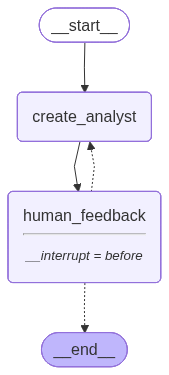

In [ ]:
from typing import Annotated, Sequence, TypedDict
from langgraph.graph import StateGraph, START, END, add_messages
from langchain_core.messages import AnyMessage
from IPython.display import Image, display



# --- Build graph ---
builder = StateGraph(GenerateAnalystsState)

# Register your nodes
builder.add_node("create_analyst", create_analyst)
builder.add_node("human_feedback", human_feedback)

# Add edges (use node names as strings)
builder.add_edge(START, "create_analyst")
builder.add_edge("create_analyst", "human_feedback")
builder.add_conditional_edges("human_feedback", should_continue, ["create_analyst", END])

# Compile graph
graph = builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)

# Visualize
display(Image(graph.get_graph().draw_mermaid_png()))
